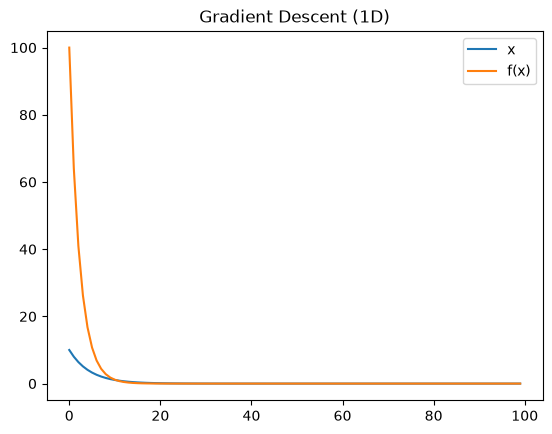

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def grad_f(x):
    return 2*x

def gradient_descent(x_init, lr, iterations):
    x = x_init
    x_history = []
    f_history = []

    for i in range(iterations):
        x_history.append(x)
        f_history.append(f(x))
        x = x - lr * grad_f(x)

    return x_history, f_history

x_hist, f_hist = gradient_descent(x_init=10, lr=0.1, iterations=100)

# Plot
plt.plot(x_hist, label='x')
plt.plot(f_hist, label='f(x)')
plt.legend()
plt.title("Gradient Descent (1D)")
plt.show()

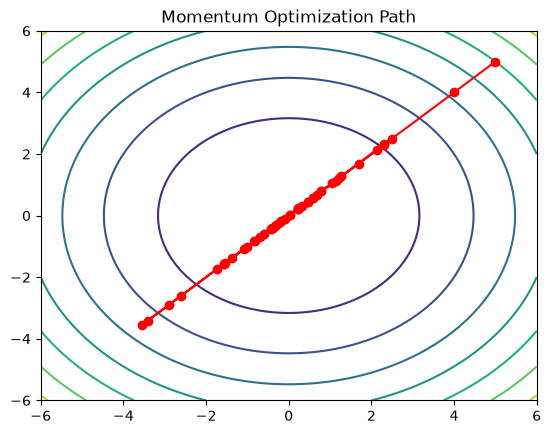

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2

def grad(x, y):
    return np.array([2*x, 2*y])

def momentum_gd(x_init, lr, momentum, iterations):
    x = np.array(x_init, dtype=float)
    v = np.zeros_like(x)
    path = []

    for _ in range(iterations):
        path.append(x.copy())
        g = grad(x[0], x[1])
        v = momentum * v - lr * g
        x = x + v

    return np.array(path)


path = momentum_gd([5, 5], lr=0.1, momentum=0.9, iterations=50)

x = np.linspace(-6,6,100)
y = np.linspace(-6,6,100)
X, Y = np.meshgrid(x,y)
Z = X**2 + Y**2

plt.contour(X,Y,Z)
plt.plot(path[:,0], path[:,1], 'r-o')
plt.title("Momentum Optimization Path")
plt.show()

In [3]:
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosen(x):
    dx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dy = 200*(x[1] - x[0]**2)
    return np.array([dx, dy])

def rmsprop(x_init, lr=0.001, beta=0.9, eps=1e-8, iterations=2000):
    x = np.array(x_init, dtype=float)
    s = np.zeros_like(x)

    for _ in range(iterations):
        g = grad_rosen(x)
        s = beta * s + (1 - beta) * (g**2)
        x = x - lr * g / (np.sqrt(s) + eps)

    return x

# Run
result = rmsprop([-1.5, 1.5])
print("Optimized:", result)

Optimized: [-0.14671997  0.0212637 ]


In [4]:
def saddle(x):
    return x[0]**2 - x[1]**2

def grad_saddle(x):
    return np.array([2*x[0], -2*x[1]])

In [5]:
def gd(x_init, lr, iterations):
    x = np.array(x_init, float)
    path = []

    for _ in range(iterations):
        path.append(x.copy())
        x -= lr * grad_saddle(x)

    return np.array(path)

In [6]:
def momentum(x_init, lr, m, iterations):
    x = np.array(x_init, float)
    v = np.zeros_like(x)
    path = []

    for _ in range(iterations):
        path.append(x.copy())
        g = grad_saddle(x)
        v = m*v - lr*g
        x += v

    return np.array(path)

In [7]:
def conjugate_gradient(x_init, lr, iterations):
    x = np.array(x_init, float)
    path = []
    d = -grad_saddle(x)

    for _ in range(iterations):
        path.append(x.copy())
        x = x + lr*d
        g_new = grad_saddle(x)
        beta = np.dot(g_new, g_new) / np.dot(d, d)
        d = -g_new + beta*d

    return np.array(path)

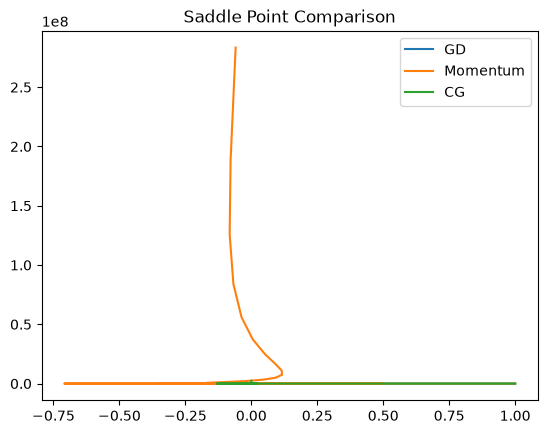

In [8]:
gd_path = gd([1,1], 0.1, 50)
mom_path = momentum([1,1], 0.1, 0.9, 50)
cg_path = conjugate_gradient([1,1], 0.1, 50)

plt.plot(gd_path[:,0], gd_path[:,1], label='GD')
plt.plot(mom_path[:,0], mom_path[:,1], label='Momentum')
plt.plot(cg_path[:,0], cg_path[:,1], label='CG')

plt.legend()
plt.title("Saddle Point Comparison")
plt.show()